In [49]:
# WEEK 3 — ADVANCED SALES PERFORMANCE ANALYSIS
# LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import micropip
await micropip.install('seaborn')

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# Seaborn settings
sns.set_theme(style="whitegrid")

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [8]:
# Convert date columns to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [9]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [10]:
# TIME FEATURES
# ============================================================

df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Month Name"] = df["Order Date"].dt.month_name()
df["Order Quarter"] = df["Order Date"].dt.quarter
df["Year-Month"] = df["Order Date"].dt.to_period("M").astype(str)

In [11]:
df[
    [
        "Order Date",
        "Order Year",
        "Order Month",
        "Order Month Name",
        "Order Quarter",
        "Year-Month"
    ]
].head()

,Order Date,Order Year,Order Month,Order Month Name,Order Quarter,Year-Month
0,2016-11-08,2016,11,November,4,2016-11
1,2016-11-08,2016,11,November,4,2016-11
2,2016-06-12,2016,6,June,2,2016-06
3,2015-10-11,2015,10,October,4,2015-10
4,2015-10-11,2015,10,October,4,2015-10


In [12]:
# OVERALL SALES PERFORMANCE
# ============================================================

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

profit_margin = total_profit / total_sales

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2%}")
print(f"Total Quantity: {total_quantity:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Profit Margin: 12.47%
Total Quantity: 37,873
Total Orders: 5,009
Total Customers: 793


In [13]:
# YEARLY SALES PERFORMANCE
# ============================================================

yearly_sales = (
    df.groupby("Order Year")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum"),
          Orders=("Order ID", "nunique")
      )
      .reset_index()
)

yearly_sales["Profit Margin"] = (
    yearly_sales["Profit"] / yearly_sales["Sales"]
)

yearly_sales

,Order Year,Sales,Profit,Quantity,Orders,Profit Margin
0,2014,"484,247.50","49,543.97",7581,969,0.10
1,2015,"470,532.51","61,618.60",7979,1038,0.13
2,2016,"609,205.60","81,795.17",9837,1315,0.13
3,2017,"733,215.26","93,439.27",12476,1687,0.13


In [14]:
yearly_sales["Sales Growth %"] = (
    yearly_sales["Sales"].pct_change() * 100
)

yearly_sales["Profit Growth %"] = (
    yearly_sales["Profit"].pct_change() * 100
)

yearly_sales

,Order Year,Sales,Profit,Quantity,Orders,Profit Margin,Sales Growth %,Profit Growth %
0,2014,"484,247.50","49,543.97",7581,969,0.10,NaN,NaN
1,2015,"470,532.51","61,618.60",7979,1038,0.13,-2.83,24.37
2,2016,"609,205.60","81,795.17",9837,1315,0.13,29.47,32.74
3,2017,"733,215.26","93,439.27",12476,1687,0.13,20.36,14.24


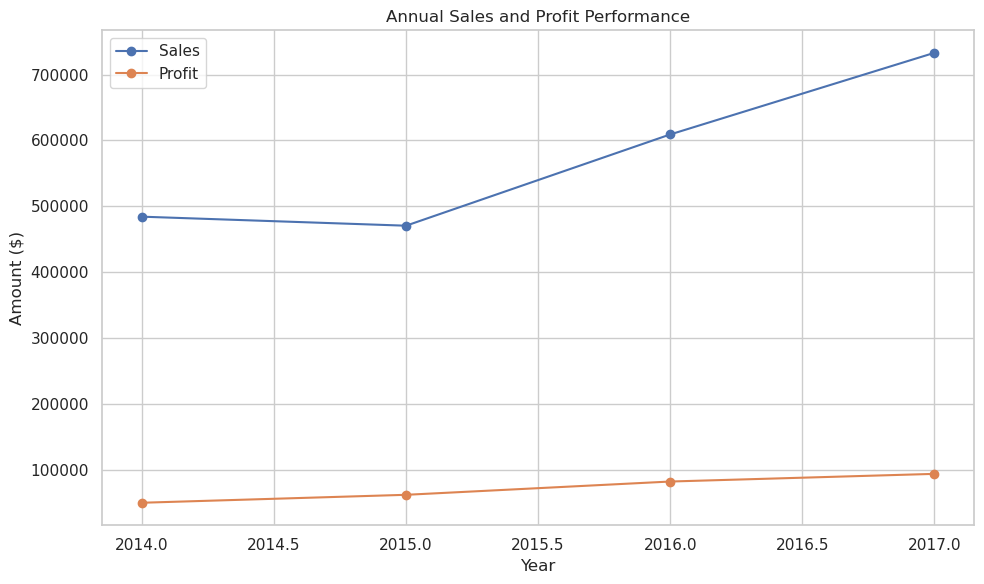

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_sales["Order Year"],
    yearly_sales["Sales"],
    marker="o",
    label="Sales"
)

plt.plot(
    yearly_sales["Order Year"],
    yearly_sales["Profit"],
    marker="o",
    label="Profit"
)

plt.title("Annual Sales and Profit Performance")
plt.xlabel("Year")
plt.ylabel("Amount ($)")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
# CATEGORY PERFORMANCE
# ============================================================

category_performance = (
    df.groupby("Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum"),
          Orders=("Order ID", "nunique")
      )
      .reset_index()
)

category_performance["Profit Margin"] = (
    category_performance["Profit"] /
    category_performance["Sales"]
)

category_performance.sort_values(
    "Profit", ascending=False
)

,Category,Sales,Profit,Quantity,Orders,Profit Margin
2,Technology,"836,154.03","145,454.95",6939,1544,0.17
1,Office Supplies,"719,047.03","122,490.80",22906,3742,0.17
0,Furniture,"741,999.80","18,451.27",8028,1764,0.02


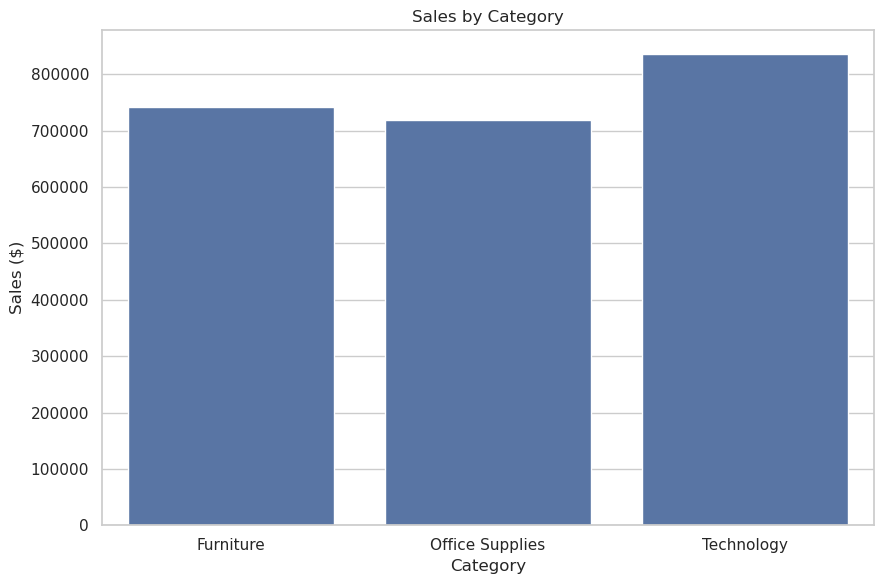

In [17]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=category_performance,
    x="Category",
    y="Sales"
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales ($)")

plt.tight_layout()
plt.show()

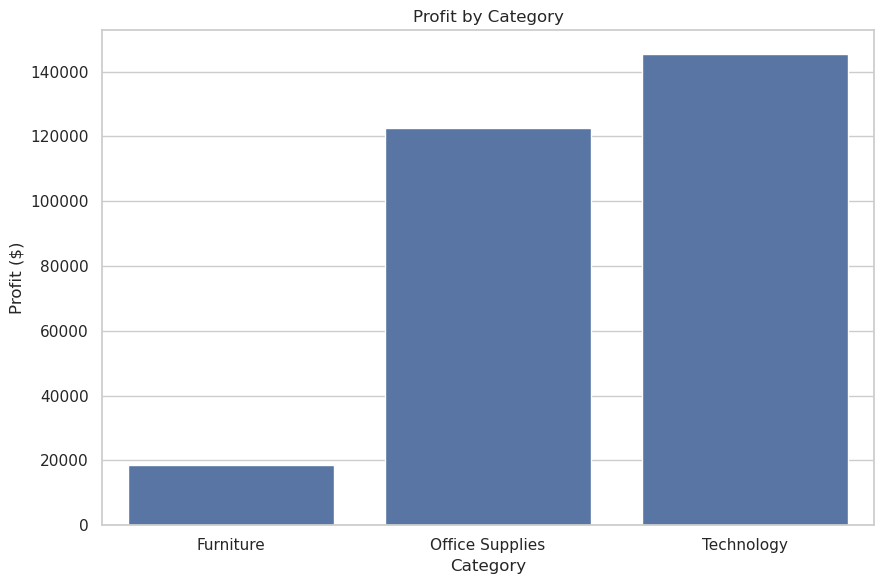

In [18]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=category_performance,
    x="Category",
    y="Profit"
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit ($)")

plt.tight_layout()
plt.show()

In [19]:
# SUB-CATEGORY PROFITABILITY
# ============================================================

subcategory_performance = (
    df.groupby("Sub-Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum"),
          Orders=("Order ID", "nunique"),
          Average_Discount=("Discount", "mean")
      )
      .reset_index()
)

subcategory_performance["Profit Margin"] = (
    subcategory_performance["Profit"] /
    subcategory_performance["Sales"]
)

subcategory_performance.sort_values(
    "Profit", ascending=True
)

,Sub-Category,Sales,Profit,Quantity,Orders,Average_Discount,Profit Margin
16,Tables,"206,965.53","-17,725.48",1241,307,0.26,-0.09
4,Bookcases,"114,880.00","-3,472.56",868,224,0.21,-0.03
15,Supplies,"46,673.54","-1,189.10",647,187,0.08,-0.03
8,Fasteners,"3,024.28",949.52,914,215,0.08,0.31
11,Machines,"189,238.63","3,384.76",440,112,0.31,0.02
10,Labels,"12,486.31","5,546.25",1400,346,0.07,0.44
2,Art,"27,118.79","6,527.79",3000,731,0.07,0.24
7,Envelopes,"16,476.40","6,964.18",906,249,0.08,0.42
9,Furnishings,"91,705.16","13,059.14",3563,877,0.14,0.14
1,Appliances,"107,532.16","18,138.01",1729,451,0.17,0.17


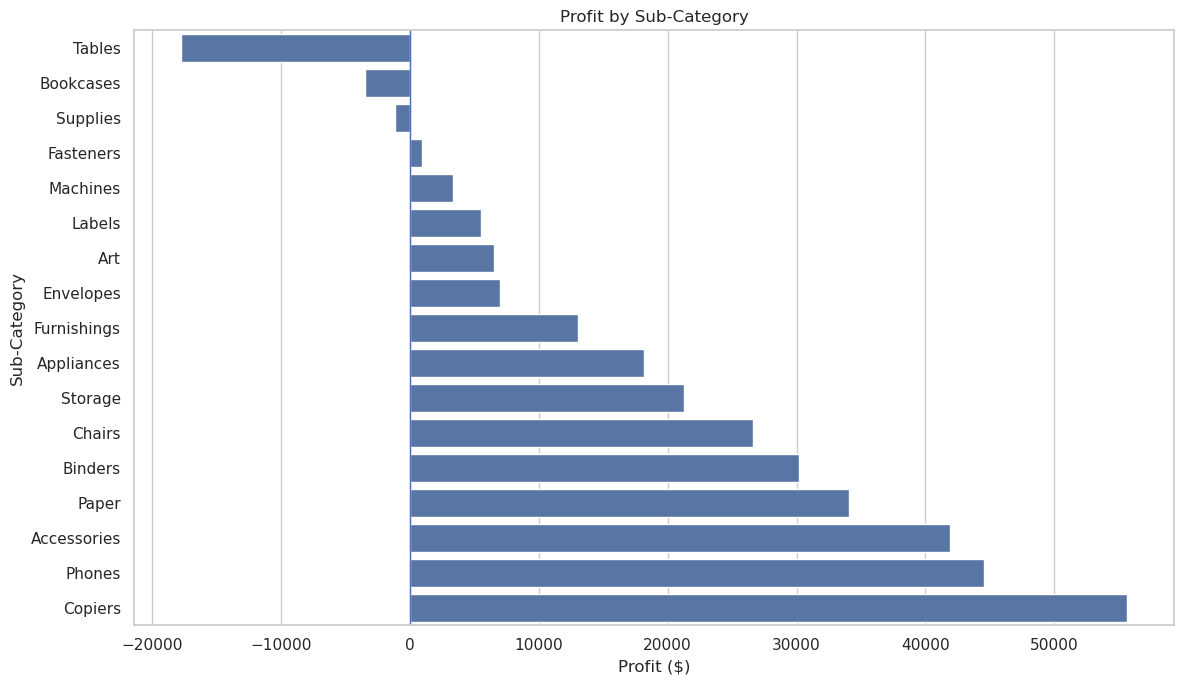

In [20]:
plt.figure(figsize=(12, 7))

plot_data = subcategory_performance.sort_values("Profit")

sns.barplot(
    data=plot_data,
    y="Sub-Category",
    x="Profit"
)

plt.axvline(0, linewidth=1)

plt.title("Profit by Sub-Category")
plt.xlabel("Profit ($)")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

In [21]:
# FURNITURE ANALYSIS
# ============================================================

furniture = df[df["Category"] == "Furniture"]

furniture_analysis = (
    furniture.groupby("Sub-Category")
             .agg(
                 Sales=("Sales", "sum"),
                 Profit=("Profit", "sum"),
                 Quantity=("Quantity", "sum"),
                 Orders=("Order ID", "nunique"),
                 Average_Discount=("Discount", "mean")
             )
             .reset_index()
)

furniture_analysis["Profit Margin"] = (
    furniture_analysis["Profit"] /
    furniture_analysis["Sales"]
)

furniture_analysis.sort_values("Profit")

,Sub-Category,Sales,Profit,Quantity,Orders,Average_Discount,Profit Margin
3,Tables,"206,965.53","-17,725.48",1241,307,0.26,-0.09
0,Bookcases,"114,880.00","-3,472.56",868,224,0.21,-0.03
2,Furnishings,"91,705.16","13,059.14",3563,877,0.14,0.14
1,Chairs,"328,449.10","26,590.17",2356,576,0.17,0.08


In [22]:
# PRODUCT PERFORMANCE
# ============================================================

product_performance = (
    df.groupby(["Product ID", "Product Name"])
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum"),
          Orders=("Order ID", "nunique"),
          Average_Discount=("Discount", "mean")
      )
      .reset_index()
)

product_performance["Profit Margin"] = (
    product_performance["Profit"] /
    product_performance["Sales"]
)

In [23]:
top_10_products = (
    product_performance
    .sort_values("Profit", ascending=False)
    .head(10)
)

top_10_products

,Product ID,Product Name,Sales,Profit,Quantity,Orders,Average_Discount,Profit Margin
1640,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,"61,599.82","25,199.93",20,5,0.12,0.41
787,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,"27,453.38","7,753.04",31,10,0.24,0.28
1630,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,"18,839.69","6,983.88",38,8,0.20,0.37
1637,TEC-CO-10003763,Canon PC1060 Personal Laser Copier,"11,619.83","4,570.93",19,4,0.15,0.39
1657,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,"18,374.90","4,094.98",12,3,0.17,0.22
1693,TEC-MA-10003979,Ativa V4110MDD Micro-Cut Shredder,"7,699.89","3,772.95",11,2,0.00,0.49
1656,TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta","14,299.89","3,717.97",11,2,0.00,0.26
1541,TEC-AC-10002049,Plantronics Savi W720 Multi-Device Wireless He...,"9,367.29","3,696.28",24,7,0.06,0.39
692,OFF-BI-10001120,Ibico EPK-21 Electric Binding System,"15,875.92","3,345.28",13,3,0.33,0.21
1643,TEC-MA-10000045,Zebra ZM400 Thermal Label Printer,"6,965.70","3,343.54",6,2,0.00,0.48


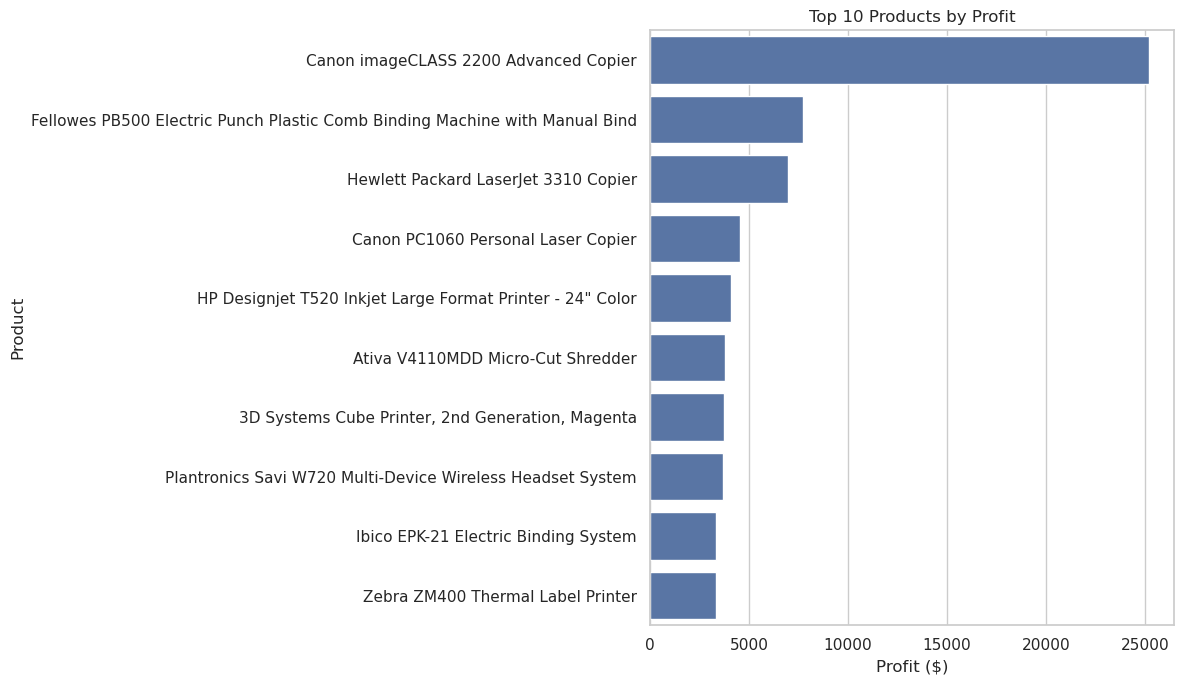

In [24]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_10_products,
    y="Product Name",
    x="Profit"
)

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit ($)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [25]:
loss_making_products = (
    product_performance[
        product_performance["Profit"] < 0
    ]
    .sort_values("Profit")
)

loss_making_products.head(10)

,Product ID,Product Name,Sales,Profit,Quantity,Orders,Average_Discount,Profit Margin
1645,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,"11,099.96","-8,879.97",9,3,0.53,-0.80
1650,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,"16,829.90","-4,589.97",18,4,0.40,-0.27
1696,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,"7,999.98","-3,839.99",4,1,0.50,-0.48
326,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,"9,917.64","-2,876.12",27,5,0.28,-0.29
344,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,"9,544.73","-1,934.40",33,7,0.35,-0.20
858,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,"17,965.07","-1,878.17",27,6,0.45,-0.10
1669,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,"22,638.48","-1,811.08",6,1,0.50,-0.08
1465,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,"16,656.20","-1,299.18",22,6,0.10,-0.08
346,FUR-TA-10001950,Balt Solid Wood Round Tables,"6,518.75","-1,201.06",19,4,0.20,-0.18
375,FUR-TA-10004289,BoxOffice By Design Rectangular and Half-Moon ...,"1,706.25","-1,148.44",15,3,0.48,-0.67


In [26]:
high_sales_low_profit = product_performance[
    (product_performance["Sales"] > 5000) &
    (product_performance["Profit"] < 0)
].sort_values(
    "Sales",
    ascending=False
)

high_sales_low_profit

,Product ID,Product Name,Sales,Profit,Quantity,Orders,Average_Discount,Profit Margin
1669,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,"22,638.48","-1,811.08",6,1,0.50,-0.08
858,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,"17,965.07","-1,878.17",27,6,0.45,-0.10
1443,OFF-SU-10000151,High Speed Automatic Electric Letter Opener,"17,030.31",-262.00,11,3,0.07,-0.02
1650,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,"16,829.90","-4,589.97",18,4,0.40,-0.27
1465,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,"16,656.20","-1,299.18",22,6,0.10,-0.08
49,FUR-BO-10004834,"Riverside Palais Royal Lawyers Bookcase, Royal...","15,610.97",-669.54,24,5,0.23,-0.04
363,FUR-TA-10003473,Bretford Rectangular Conference Table Tops,"12,995.29",-327.23,46,12,0.25,-0.03
1645,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,"11,099.96","-8,879.97",9,3,0.53,-0.80
326,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,"9,917.64","-2,876.12",27,5,0.28,-0.29
344,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,"9,544.73","-1,934.40",33,7,0.35,-0.20


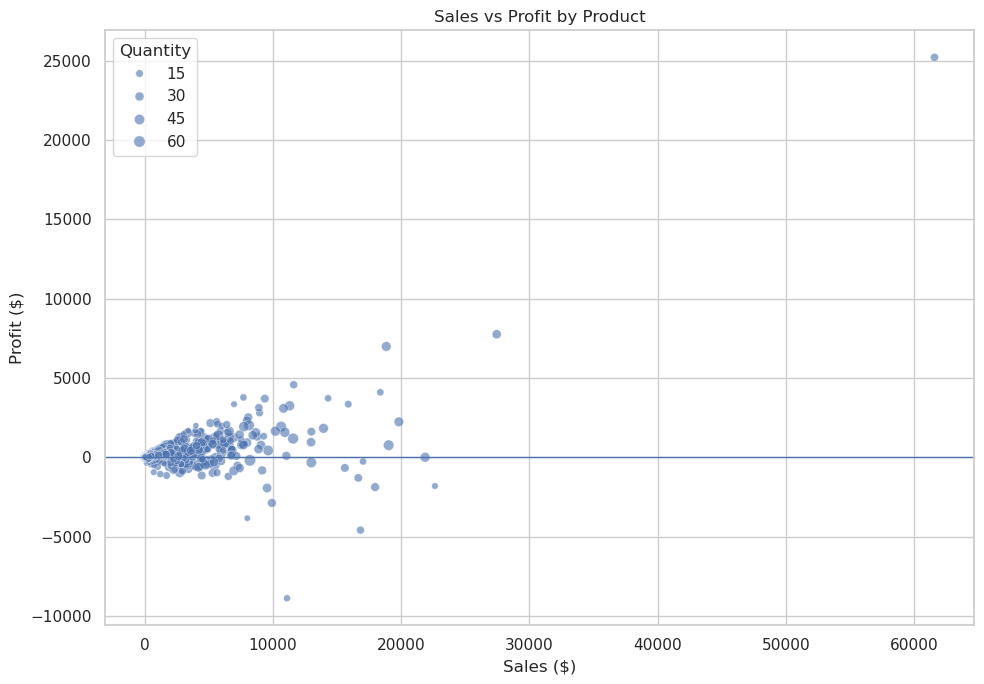

In [27]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=product_performance,
    x="Sales",
    y="Profit",
    size="Quantity",
    alpha=0.6
)

plt.axhline(0, linewidth=1)

plt.title("Sales vs Profit by Product")
plt.xlabel("Sales ($)")
plt.ylabel("Profit ($)")

plt.tight_layout()
plt.show()

In [28]:
# REGIONAL PERFORMANCE
# ============================================================

regional_performance = (
    df.groupby("Region")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique"),
          Customers=("Customer ID", "nunique")
      )
      .reset_index()
)

regional_performance["Profit Margin"] = (
    regional_performance["Profit"] /
    regional_performance["Sales"]
)

regional_performance

,Region,Sales,Profit,Orders,Customers,Profit Margin
0,Central,"501,239.89","39,706.36",1175,629,0.08
1,East,"678,781.24","91,522.78",1401,674,0.13
2,South,"391,721.91","46,749.43",822,512,0.12
3,West,"725,457.82","108,418.45",1611,686,0.15


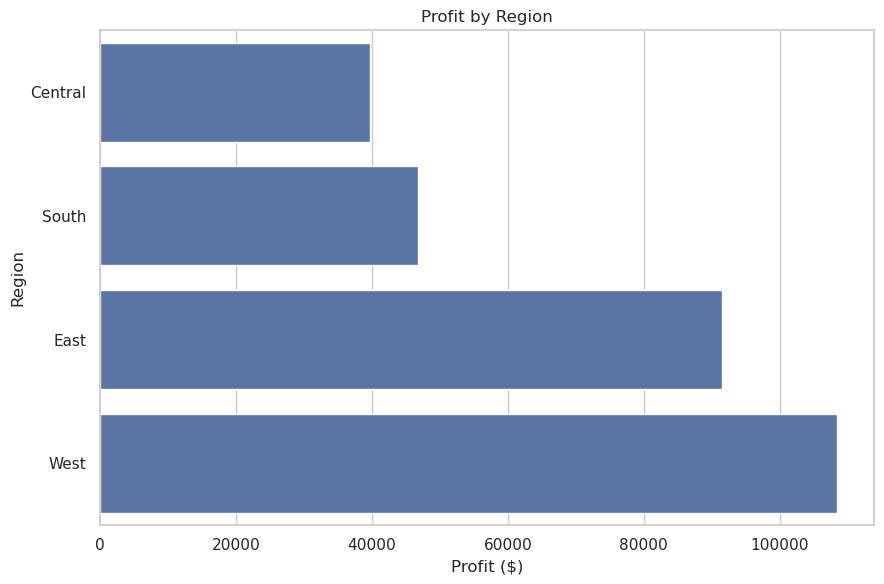

In [29]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=regional_performance.sort_values("Profit"),
    y="Region",
    x="Profit"
)

plt.title("Profit by Region")
plt.xlabel("Profit ($)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

In [30]:
# CUSTOMER SEGMENT PERFORMANCE
# ============================================================

segment_performance = (
    df.groupby("Segment")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique"),
          Customers=("Customer ID", "nunique")
      )
      .reset_index()
)

segment_performance["Profit Margin"] = (
    segment_performance["Profit"] /
    segment_performance["Sales"]
)

segment_performance

,Segment,Sales,Profit,Orders,Customers,Profit Margin
0,Consumer,"1,161,401.34","134,119.21",2586,409,0.12
1,Corporate,"706,146.37","91,979.13",1514,236,0.13
2,Home Office,"429,653.15","60,298.68",909,148,0.14


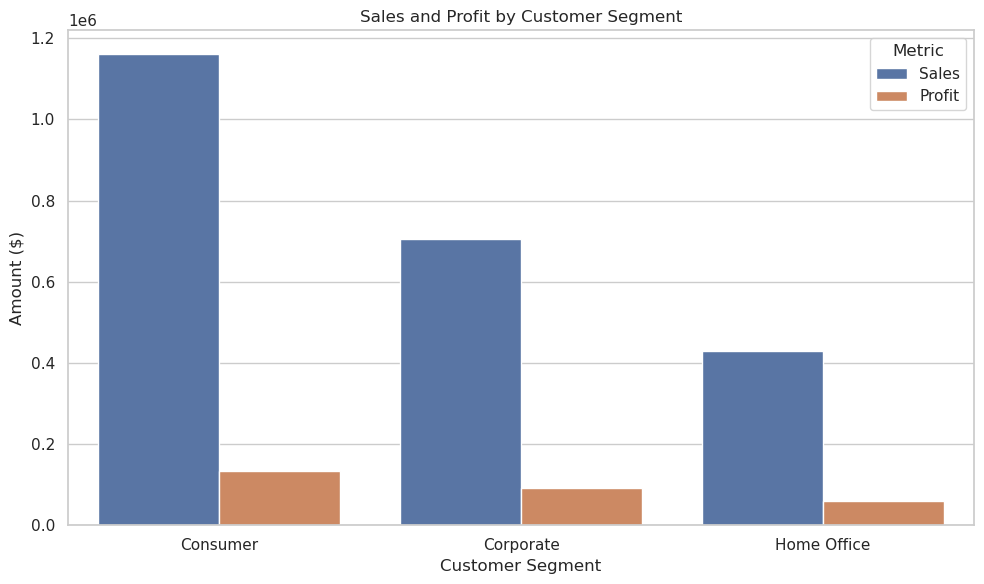

In [31]:
segment_plot = segment_performance.melt(
    id_vars="Segment",
    value_vars=["Sales", "Profit"],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_plot,
    x="Segment",
    y="Value",
    hue="Metric"
)

plt.title("Sales and Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Amount ($)")

plt.tight_layout()
plt.show()

In [32]:
# TOP CUSTOMERS
# ============================================================

customer_performance = (
    df.groupby(["Customer ID", "Customer Name"])
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique")
      )
      .reset_index()
)

customer_performance["Profit Margin"] = (
    customer_performance["Profit"] /
    customer_performance["Sales"]
)

top_customers = (
    customer_performance
    .sort_values("Profit", ascending=False)
    .head(10)
)

top_customers

,Customer ID,Customer Name,Sales,Profit,Orders,Profit Margin
741,TC-20980,Tamara Chand,"19,052.22","8,981.32",5,0.47
621,RB-19360,Raymond Buch,"15,117.34","6,976.10",6,0.46
669,SC-20095,Sanjit Chand,"14,142.33","5,757.41",9,0.41
327,HL-15040,Hunter Lopez,"12,873.30","5,622.43",6,0.44
6,AB-10105,Adrian Barton,"14,473.57","5,444.81",10,0.38
730,TA-21385,Tom Ashbrook,"14,595.62","4,703.79",4,0.32
160,CM-12385,Christopher Martinez,"8,954.02","3,899.89",4,0.44
424,KD-16495,Keith Dawkins,"8,181.26","3,038.63",12,0.37
48,AR-10540,Andy Reiter,"6,608.45","2,884.62",6,0.44
234,DR-12940,Daniel Raglin,"8,350.87","2,869.08",8,0.34


In [33]:
# DISCOUNT ANALYSIS
# ============================================================

bins = [-0.001, 0, 0.10, 0.20, 0.30, 0.50, 1.00]

labels = [
    "0%",
    ">0%-10%",
    ">10%-20%",
    ">20%-30%",
    ">30%-50%",
    ">50%"
]

df["Discount Band"] = pd.cut(
    df["Discount"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [34]:
discount_performance = (
    df.groupby("Discount Band", observed=False)
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .reset_index()
)

discount_performance["Profit Margin"] = (
    discount_performance["Profit"] /
    discount_performance["Sales"]
)

discount_performance

,Discount Band,Sales,Profit,Quantity,Profit Margin
0,0%,"1,087,908.47","320,987.60",18267,0.30
1,>0%-10%,"54,369.35","9,029.18",373,0.17
2,>10%-20%,"792,152.89","91,756.30",13858,0.12
3,>20%-30%,"103,226.65","-10,369.28",849,-0.10
4,>30%-50%,"195,314.76","-48,447.73",1177,-0.25
5,>50%,"64,228.74","-76,559.05",3349,-1.19


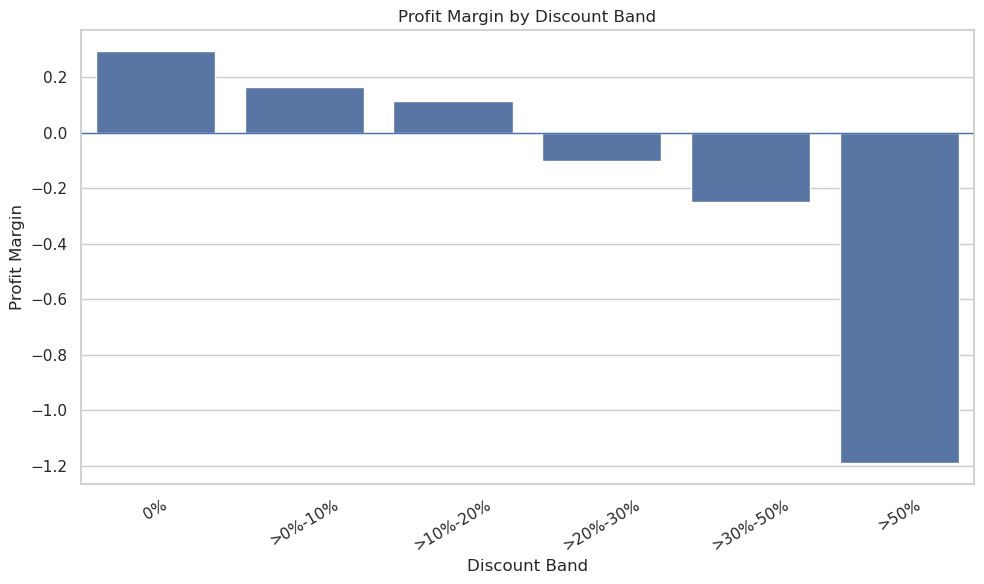

In [35]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=discount_performance,
    x="Discount Band",
    y="Profit Margin"
)

plt.axhline(0, linewidth=1)

plt.title("Profit Margin by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Profit Margin")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [36]:
# MONTHLY PERFORMANCE
# ============================================================

monthly_performance = (
    df.groupby("Year-Month")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

monthly_performance

,Year-Month,Sales,Profit
0,2014-01,"14,236.90","2,450.19"
1,2014-02,"4,519.89",862.31
2,2014-03,"55,691.01",498.73
3,2014-04,"28,295.35","3,488.84"
4,2014-05,"23,648.29","2,738.71"
5,2014-06,"34,595.13","4,976.52"
6,2014-07,"33,946.39",-841.48
7,2014-08,"27,909.47","5,318.10"
8,2014-09,"81,777.35","8,328.10"
9,2014-10,"31,453.39","3,448.26"


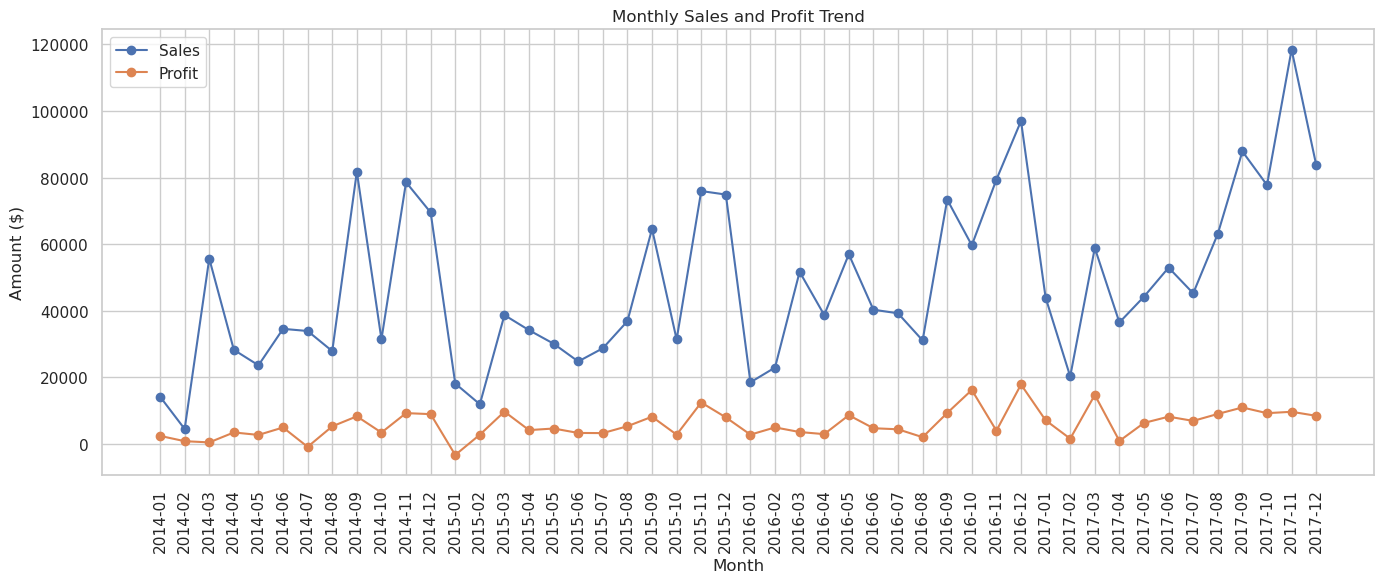

In [37]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_performance["Year-Month"],
    monthly_performance["Sales"],
    marker="o",
    label="Sales"
)

plt.plot(
    monthly_performance["Year-Month"],
    monthly_performance["Profit"],
    marker="o",
    label="Profit"
)

plt.title("Monthly Sales and Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount ($)")

plt.xticks(rotation=90)
plt.legend()

plt.tight_layout()
plt.show()

In [38]:
quarterly_performance = (
    df.groupby(["Order Year", "Order Quarter"])
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

quarterly_performance["Profit Margin"] = (
    quarterly_performance["Profit"] /
    quarterly_performance["Sales"]
)

quarterly_performance

,Order Year,Order Quarter,Sales,Profit,Profit Margin
0,2014,1,"74,447.80","3,811.23",0.05
1,2014,2,"86,538.76","11,204.07",0.13
2,2014,3,"143,633.21","12,804.72",0.09
3,2014,4,"179,627.73","21,723.95",0.12
4,2015,1,"68,851.74","9,264.94",0.13
5,2015,2,"89,124.19","12,190.92",0.14
6,2015,3,"130,259.58","16,853.62",0.13
7,2015,4,"182,297.01","23,309.12",0.13
8,2016,1,"93,237.18","11,441.37",0.12
9,2016,2,"136,082.30","16,390.34",0.12


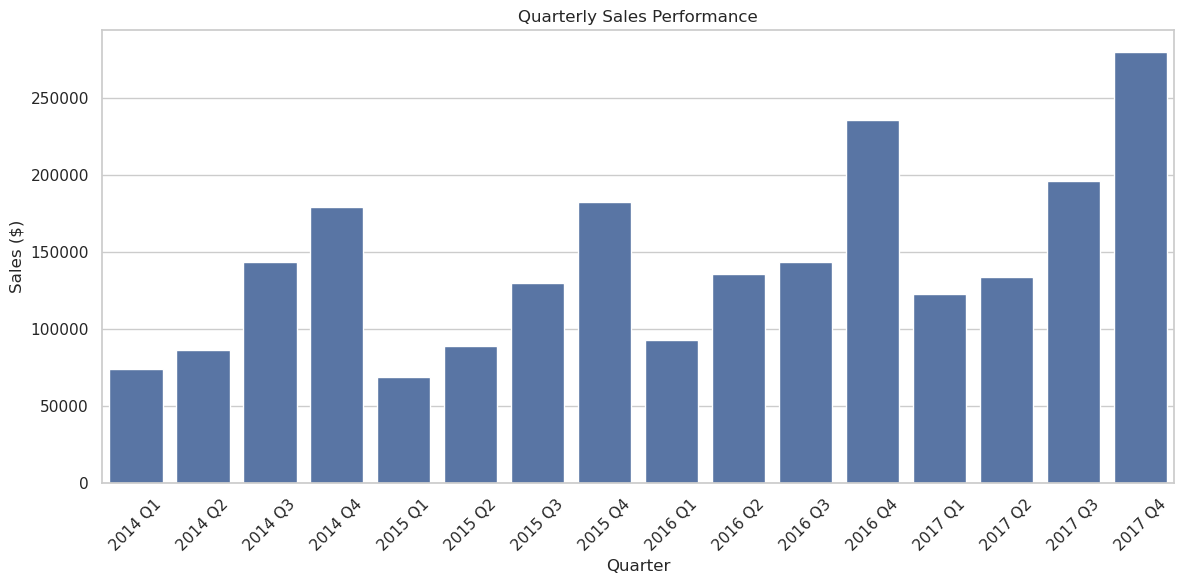

In [39]:
quarterly_performance["Quarter"] = (
    quarterly_performance["Order Year"].astype(str)
    + " Q"
    + quarterly_performance["Order Quarter"].astype(str)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=quarterly_performance,
    x="Quarter",
    y="Sales"
)

plt.title("Quarterly Sales Performance")
plt.xlabel("Quarter")
plt.ylabel("Sales ($)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [40]:
furniture_summary = (
    df[df["Category"] == "Furniture"]
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
)

furniture_summary["Profit Margin"] = (
    furniture_summary["Profit"] /
    furniture_summary["Sales"]
)

furniture_summary

,Sales,Profit,Profit Margin
Sales,"741,999.80",NaN,NaN
Profit,NaN,"18,451.27",NaN


In [41]:
loss_summary = (
    product_performance[
        product_performance["Profit"] < 0
    ]
)

print(
    f"Number of loss-making products: "
    f"{len(loss_summary):,}"
)

Number of loss-making products: 306


In [42]:
regional_performance.sort_values(
    "Profit Margin"
)

,Region,Sales,Profit,Orders,Customers,Profit Margin
0,Central,"501,239.89","39,706.36",1175,629,0.08
2,South,"391,721.91","46,749.43",822,512,0.12
1,East,"678,781.24","91,522.78",1401,674,0.13
3,West,"725,457.82","108,418.45",1611,686,0.15


In [43]:
discount_performance[
    ["Discount Band", "Sales", "Profit", "Profit Margin"]
]

,Discount Band,Sales,Profit,Profit Margin
0,0%,"1,087,908.47","320,987.60",0.30
1,>0%-10%,"54,369.35","9,029.18",0.17
2,>10%-20%,"792,152.89","91,756.30",0.12
3,>20%-30%,"103,226.65","-10,369.28",-0.10
4,>30%-50%,"195,314.76","-48,447.73",-0.25
5,>50%,"64,228.74","-76,559.05",-1.19


In [44]:
correlation_data = df[
    [
        "Sales",
        "Quantity",
        "Discount",
        "Profit"
    ]
]

correlation_matrix = correlation_data.corr()

correlation_matrix

,Sales,Quantity,Discount,Profit
Sales,1.00,0.20,-0.03,0.48
Quantity,0.20,1.00,0.01,0.07
Discount,-0.03,0.01,1.00,-0.22
Profit,0.48,0.07,-0.22,1.00


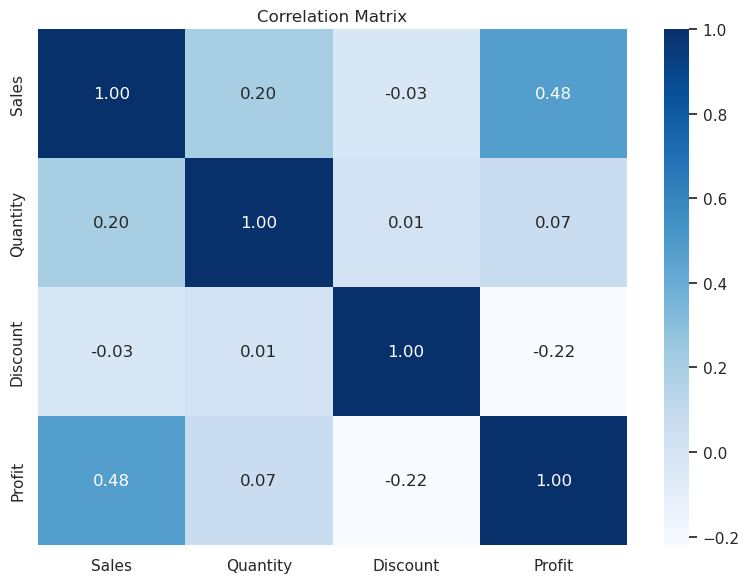

In [45]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [46]:
final_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Profit Margin",
        "Total Orders",
        "Total Customers",
        "Total Quantity"
    ],
    "Value": [
        total_sales,
        total_profit,
        profit_margin,
        total_orders,
        total_customers,
        total_quantity
    ]
})

final_summary

,Metric,Value
0,Total Sales,"2,297,200.86"
1,Total Profit,"286,397.02"
2,Profit Margin,0.12
3,Total Orders,"5,009.00"
4,Total Customers,793.00
5,Total Quantity,"37,873.00"


In [47]:
from pathlib import Path

OUTPUT_PATH = Path(r"C:\AnalystLab_Week3\Analysis_Results")

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

print(f"Output folder: {OUTPUT_PATH}")

Output folder: C:\AnalystLab_Week3\Analysis_Results


In [48]:
# Export analysis results

yearly_sales.to_csv(
    OUTPUT_PATH / "yearly_sales_performance.csv",
    index=False
)

category_performance.to_csv(
    OUTPUT_PATH / "category_performance.csv",
    index=False
)

subcategory_performance.to_csv(
    OUTPUT_PATH / "subcategory_performance.csv",
    index=False
)

product_performance.to_csv(
    OUTPUT_PATH / "product_performance.csv",
    index=False
)

regional_performance.to_csv(
    OUTPUT_PATH / "regional_performance.csv",
    index=False
)

segment_performance.to_csv(
    OUTPUT_PATH / "segment_performance.csv",
    index=False
)

discount_performance.to_csv(
    OUTPUT_PATH / "discount_performance.csv",
    index=False
)

print("All analysis CSV files exported successfully.")

All analysis CSV files exported successfully.
